# Context-Aware CNN1D ECG Arrhythmia Detection - Training

## Objective
Train a context-aware CNN1D model for binary ECG arrhythmia classification using temporal beat windows.

## Key Features
1. **Context Input**: 7 beats (3 previous + 1 center + 3 subsequent)
2. **Normalization**: Fit scaler on TRAINING DATA ONLY (no data leakage)
3. **Model**: Context-aware CNN1D with proper architecture
4. **Output**: ONNX model + scaler for deployment

## Input Requirements
- X_train.npy, y_train.npy
- X_val.npy, y_val.npy
- X_test.npy, y_test.npy
- dataset_config.json

Generated by: mitbih_context_dataset_creator.ipynb

## STEP 1: Import Libraries

In [66]:
!rm -rf /kaggle/working/*

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score,
    log_loss, mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)  # automatically uses all GPUs
model.to(device)
print(f'Using device: {device}')

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_STATE)

PyTorch version: 2.8.0+cu126
CUDA available: True
Using 2 GPUs
Using device: cuda


## STEP 2: Load Dataset

In [68]:
# Try Kaggle path first, then local
KAGGLE_INPUT = '/kaggle/input/patient-wise-per-beat-ecg/'
KAGGLE_WORKING = '/kaggle/working/'
LOCAL_PATH = './'

if os.path.exists(os.path.join(KAGGLE_INPUT, 'X_train.npy')):
    DATA_PATH = KAGGLE_INPUT
elif os.path.exists(os.path.join(KAGGLE_WORKING, 'X_train.npy')):
    DATA_PATH = KAGGLE_WORKING
elif os.path.exists(os.path.join(LOCAL_PATH, 'X_train.npy')):
    DATA_PATH = LOCAL_PATH
else:
    raise FileNotFoundError('Dataset not found! Run mitbih_context_dataset_creator.ipynb first.')

print(f'Loading data from: {DATA_PATH}')

# Load numpy arrays
X_train = np.load(os.path.join(DATA_PATH, 'X_train.npy'))
y_train = np.load(os.path.join(DATA_PATH, 'y_train.npy'))
X_val = np.load(os.path.join(DATA_PATH, 'X_val.npy'))
y_val = np.load(os.path.join(DATA_PATH, 'y_val.npy'))
X_test = np.load(os.path.join(DATA_PATH, 'X_test.npy'))
y_test = np.load(os.path.join(DATA_PATH, 'y_test.npy'))

print(f'\nData shapes:')
print(f'  X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'  X_val: {X_val.shape}, y_val: {y_val.shape}')
print(f'  X_test: {X_test.shape}, y_test: {y_test.shape}')

# Load config
config_path = os.path.join(DATA_PATH, 'dataset_config.json')
if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        dataset_config = json.load(f)
    print(f'\nDataset config:')
    print(f'  Context window size: {dataset_config["context_window_size"]}')
    print(f'  Beat length: {dataset_config["beat_length"]}')
else:
    dataset_config = {
        'context_window_size': 7,
        'beat_length': 200
    }
    print('Warning: dataset_config.json not found, using defaults')

CONTEXT_WINDOW_SIZE = dataset_config['context_window_size']
BEAT_LENGTH = dataset_config['beat_length']

Loading data from: /kaggle/input/patient-wise-per-beat-ecg/

Data shapes:
  X_train: (75343, 7, 200), y_train: (75343,)
  X_val: (14745, 7, 200), y_val: (14745,)
  X_test: (17814, 7, 200), y_test: (17814,)

Dataset config:
  Context window size: 7
  Beat length: 200


## Step 2.1 Summary of npy files

In [69]:
import numpy as np
import os

DATA_FOLDER = '/kaggle/input/patient-wise-per-beat-ecg'
CONTEXT_WINDOW_SIZE = 7
BEAT_LENGTH = 200

def inspect_npy(path, name):
    print(f'\n{name}')
    print('-' * len(name))
    try:
        arr = np.load(path, allow_pickle=False)
    except Exception as e:
        print(f'  Error loading {name}: {e}')
        return None

    print(f'  Type: {type(arr)}')
    print(f'  Dtype: {arr.dtype}')
    print(f'  Shape: {arr.shape}')
    
    # Show sample element
    if arr.ndim >= 1:
        print(f'  First element type: {type(arr[0])}')
    
    if arr.ndim <= 3:
        print(f'  Example slice:\n{arr[0]}')
    else:
        print(f'  Example slice shape: {arr[0].shape}')
    
    # Summary statistics for numeric arrays
    if np.issubdtype(arr.dtype, np.number):
        print(f'  Min / Max: {arr.min():.3f} / {arr.max():.3f}')
        print(f'  Mean ± Std: {arr.mean():.3f} ± {arr.std():.3f}')
    
    return arr

def summarize_ecg_array(arr, name):
    if arr.ndim == 3:
        print(f'\nECG tensor check for {name}:')
        print(f'  Total beats: {arr.shape[0]}')
        print(f'  Context window: {arr.shape[1]}')
        print(f'  Beat length: {arr.shape[2]}')
    elif arr.ndim == 1:
        print(f'\nLabel vector {name}:')
        print(f'  Total elements: {arr.shape[0]}')
        print(f'  Classes: {np.unique(arr)}')

npy_files = [f for f in os.listdir(DATA_FOLDER) if f.endswith('.npy')]
if not npy_files:
    raise FileNotFoundError(f'No .npy files found in {DATA_FOLDER}')

print(f'Found {len(npy_files)} .npy files in {DATA_FOLDER}: {npy_files}')

loaded_arrays = {}

for fname in npy_files:
    path = os.path.join(DATA_FOLDER, fname)
    arr = inspect_npy(path, fname)
    if arr is not None:
        loaded_arrays[fname] = arr

for name in ['X_train.npy', 'X_val.npy', 'X_test.npy']:
    if name in loaded_arrays:
        summarize_ecg_array(loaded_arrays[name], name)

for name in ['y_train.npy', 'y_val.npy', 'y_test.npy']:
    if name in loaded_arrays:
        summarize_ecg_array(loaded_arrays[name], name)

# Optional: check patient_ids if exists
patient_file = 'patient_ids.npy'
if patient_file in loaded_arrays:
    patient_ids = loaded_arrays[patient_file]
    print(f'\nPatient IDs check:')
    print(f'  Total beats: {patient_ids.shape[0]}')
    print(f'  Total unique patients: {len(np.unique(patient_ids))}')
    print(f'  Example IDs: {np.unique(patient_ids)[:10]}')


Found 6 .npy files in /kaggle/input/patient-wise-per-beat-ecg: ['y_train.npy', 'y_test.npy', 'y_val.npy', 'X_test.npy', 'X_val.npy', 'X_train.npy']

y_train.npy
-----------
  Type: <class 'numpy.ndarray'>
  Dtype: int64
  Shape: (75343,)
  First element type: <class 'numpy.int64'>
  Example slice:
1
  Min / Max: 0.000 / 1.000
  Mean ± Std: 0.286 ± 0.452

y_test.npy
----------
  Type: <class 'numpy.ndarray'>
  Dtype: int64
  Shape: (17814,)
  First element type: <class 'numpy.int64'>
  Example slice:
0
  Min / Max: 0.000 / 1.000
  Mean ± Std: 0.222 ± 0.415

y_val.npy
---------
  Type: <class 'numpy.ndarray'>
  Dtype: int64
  Shape: (14745,)
  First element type: <class 'numpy.int64'>
  Example slice:
1
  Min / Max: 0.000 / 1.000
  Mean ± Std: 0.617 ± 0.486

X_test.npy
----------
  Type: <class 'numpy.ndarray'>
  Dtype: float32
  Shape: (17814, 7, 200)
  First element type: <class 'numpy.ndarray'>
  Example slice:
[[864. 862. 862. ... 899. 903. 901.]
 [859. 858. 859. ... 886. 887. 886.]


## STEP 3: Validate Data Shapes

In [70]:
# Validate shapes
expected_shape = (CONTEXT_WINDOW_SIZE, BEAT_LENGTH)
assert X_train[0].shape == expected_shape, f'Expected {expected_shape}, got {X_train[0].shape}'
assert X_val[0].shape == expected_shape, f'Expected {expected_shape}, got {X_val[0].shape}'
assert X_test[0].shape == expected_shape, f'Expected {expected_shape}, got {X_test[0].shape}'

print(f'✓ Data shapes validated: {expected_shape}')

# Class distribution
print(f'\nClass distribution:')
print(f'  Train: Normal={np.sum(y_train == 0)}, Abnormal={np.sum(y_train == 1)}')
print(f'  Val: Normal={np.sum(y_val == 0)}, Abnormal={np.sum(y_val == 1)}')
print(f'  Test: Normal={np.sum(y_test == 0)}, Abnormal={np.sum(y_test == 1)}')

✓ Data shapes validated: (7, 200)

Class distribution:
  Train: Normal=53802, Abnormal=21541
  Val: Normal=5650, Abnormal=9095
  Test: Normal=13863, Abnormal=3951


## STEP 4: Normalization - FIT ON TRAINING ONLY

- Flatten input as (samples, context_window_size * beat_length) for scaling
- Fit scaler on TRAINING DATA ONLY
- Transform val and test using training statistics

In [71]:
# Flatten for scaling: (samples, 7, 200) -> (samples, 1400)
n_train = len(X_train)
n_val = len(X_val)
n_test = len(X_test)
flat_size = CONTEXT_WINDOW_SIZE * BEAT_LENGTH

X_train_flat = X_train.reshape(n_train, flat_size)
X_val_flat = X_val.reshape(n_val, flat_size)
X_test_flat = X_test.reshape(n_test, flat_size)

print(f'Flattened shapes:')
print(f'  X_train_flat: {X_train_flat.shape}')
print(f'  X_val_flat: {X_val_flat.shape}')
print(f'  X_test_flat: {X_test_flat.shape}')

# Fit scaler on TRAINING DATA ONLY
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train_flat)  # FIT on training only!
X_val_norm = scaler.transform(X_val_flat)           # Transform using training stats
X_test_norm = scaler.transform(X_test_flat)         # Transform using training stats

print(f'\nNormalization applied (training statistics only):')
print(f'  Train - Mean: {X_train_norm.mean():.6f}, Std: {X_train_norm.std():.6f}')
print(f'  Val - Mean: {X_val_norm.mean():.6f}, Std: {X_val_norm.std():.6f}')
print(f'  Test - Mean: {X_test_norm.mean():.6f}, Std: {X_test_norm.std():.6f}')

# Reshape back to (samples, context_window_size, beat_length)
X_train_norm = X_train_norm.reshape(n_train, CONTEXT_WINDOW_SIZE, BEAT_LENGTH)
X_val_norm = X_val_norm.reshape(n_val, CONTEXT_WINDOW_SIZE, BEAT_LENGTH)
X_test_norm = X_test_norm.reshape(n_test, CONTEXT_WINDOW_SIZE, BEAT_LENGTH)

print(f'\nReshaped for CNN:')
print(f'  X_train_norm: {X_train_norm.shape}')
print(f'  X_val_norm: {X_val_norm.shape}')
print(f'  X_test_norm: {X_test_norm.shape}')

Flattened shapes:
  X_train_flat: (75343, 1400)
  X_val_flat: (14745, 1400)
  X_test_flat: (17814, 1400)

Normalization applied (training statistics only):
  Train - Mean: -0.000000, Std: 1.000000
  Val - Mean: 0.052375, Std: 0.992120
  Test - Mean: -0.092125, Std: 1.103607

Reshaped for CNN:
  X_train_norm: (75343, 7, 200)
  X_val_norm: (14745, 7, 200)
  X_test_norm: (17814, 7, 200)


## STEP 5: PyTorch Dataset

In [72]:
class ContextECGDataset(Dataset):
    def __init__(self, X, y):
        # X: (samples, context_window_size, beat_length)
        # For Conv1d, we need (samples, channels, length)
        # Here channels = context_window_size = 7
        self.X = torch.FloatTensor(X)  # (N, 7, 200)
        self.y = torch.LongTensor(y)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = ContextECGDataset(X_train_norm, y_train)
val_dataset = ContextECGDataset(X_val_norm, y_val)
test_dataset = ContextECGDataset(X_test_norm, y_test)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'DataLoaders created:')
print(f'  Train batches: {len(train_loader)}')
print(f'  Val batches: {len(val_loader)}')
print(f'  Test batches: {len(test_loader)}')

DataLoaders created:
  Train batches: 1177
  Val batches: 231
  Test batches: 279


## STEP 6: Context-Aware CNN1D Model

Architecture:
- Input: (7, 200) - 7 beats of 200 samples each
- Conv1D layers with increasing filters
- BatchNormalization + ReLU
- GlobalAveragePooling
- Dense layers with Dropout
- Sigmoid output for binary classification

In [73]:
class ContextAwareCNN1D(nn.Module):
    """
    Context-aware CNN1D for ECG arrhythmia detection.
    
    Input: (batch, 7, 200)
    Output: (batch, 2)
    """
    def __init__(self, context_window_size=7, beat_length=200, dropout=0.7):
        super().__init__()
        
        # 32 → 16
        self.conv1 = nn.Sequential(
            nn.Conv1d(context_window_size, 16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        
        # 64 → 32
        self.conv2 = nn.Sequential(
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        
        # 128 → 64
        self.conv3 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        # Classifier adjusted accordingly
        self.classifier = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        x = self.conv1(x)     # (batch, 16, 100)
        x = self.conv2(x)     # (batch, 32, 50)
        x = self.conv3(x)     # (batch, 64, 25)
        x = self.global_pool(x)
        x = x.squeeze(-1)     # (batch, 64)
        x = self.classifier(x)
        return x



model = ContextAwareCNN1D(
    context_window_size=CONTEXT_WINDOW_SIZE,
    beat_length=BEAT_LENGTH,
    dropout=0.5
).to(device)

print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

ContextAwareCNN1D(
  (conv1): Sequential(
    (0): Conv1d(7, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv1d(32, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (global_pool): AdaptiveAvgPool1d(output_size=1)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, 

## STEP 7: Training Configuration

In [74]:
# Compute class weights for imbalanced data
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.FloatTensor(class_weights).to(device)
print(f'Class weights: {class_weights}')

# Loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer with L2 regularization
optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay = 1e-4  # L2 regularization
)

# Learning rate scheduler - reduce on plateau based on val AUC
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-6
)

print('\nTraining configuration:')
print('  Optimizer: AdamW (lr=0.001, weight_decay=1e-3)')
print('  Loss: CrossEntropyLoss with class weights')
print('  Scheduler: ReduceLROnPlateau (based on val AUC)')

Class weights: tensor([0.7002, 1.7488], device='cuda:0')

Training configuration:
  Optimizer: AdamW (lr=0.001, weight_decay=1e-3)
  Loss: CrossEntropyLoss with class weights
  Scheduler: ReduceLROnPlateau (based on val AUC)


## STEP 8: Training Functions

In [75]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    all_probs = []
    all_labels = []
    
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
        _, preds = outputs.max(1)
        total += y_batch.size(0)
        correct += preds.eq(y_batch).sum().item()
        
        probs = torch.softmax(outputs, dim=1)[:, 1]
        all_probs.extend(probs.cpu().detach().numpy())
        all_labels.extend(y_batch.cpu().numpy())
    
    acc = correct / total
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = 0.0
    
    return total_loss / len(loader), acc, auc


def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            total_loss += loss.item()
            _, preds = outputs.max(1)
            total += y_batch.size(0)
            correct += preds.eq(y_batch).sum().item()
            
            probs = torch.softmax(outputs, dim=1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    
    acc = correct / total
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = 0.0
    
    recall = recall_score(all_labels, [1 if p >= 0.5 else 0 for p in all_probs], zero_division=0)
    
    return total_loss / len(loader), acc, auc, recall


print('Training functions defined')

Training functions defined


## STEP 9: Training Loop

In [76]:
NUM_EPOCHS = 100
PATIENCE = 15
best_val_auc = 0.0
patience_counter = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []
train_aucs, val_aucs = [], []

print('Starting Training...')
print('=' * 80)

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc, train_auc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_auc, val_recall = validate_epoch(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_aucs.append(train_auc)
    val_aucs.append(val_auc)
    
    scheduler.step(val_auc)
    lr = optimizer.param_groups[0]['lr']
    
    if (epoch + 1) % 5 == 0 or epoch < 5:
        print(f'Epoch [{epoch+1:3d}/{NUM_EPOCHS}] '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} AUC: {train_auc:.4f} | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} AUC: {val_auc:.4f} Recall: {val_recall:.4f} | '
              f'LR: {lr:.6f}')
    
    # Early stopping based on AUC
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_auc': val_auc,
            'val_acc': val_acc,
            'val_recall': val_recall,
        }, 'context_ecg_model_best.pth')
        if (epoch + 1) % 5 == 0:
            print(f'  -> New best model saved (AUC: {val_auc:.4f})')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch+1}')
            break

# Load best model
checkpoint = torch.load(
    'context_ecg_model_best.pth',
    weights_only=False,
    map_location=device
)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'\nBest model from epoch {checkpoint["epoch"]+1}:')
print(f'  Val AUC: {checkpoint["val_auc"]:.4f}')
print(f'  Val Acc: {checkpoint["val_acc"]:.4f}')
print(f'  Val Recall: {checkpoint["val_recall"]:.4f}')

Starting Training...
Epoch [  1/100] Train Loss: 0.3692 Acc: 0.8476 AUC: 0.9190 | Val Loss: 0.5292 Acc: 0.8000 AUC: 0.8669 Recall: 0.7434 | LR: 0.001000
Epoch [  2/100] Train Loss: 0.1848 Acc: 0.9427 AUC: 0.9777 | Val Loss: 0.7530 Acc: 0.7478 AUC: 0.8052 Recall: 0.6540 | LR: 0.001000
Epoch [  3/100] Train Loss: 0.1418 Acc: 0.9577 AUC: 0.9860 | Val Loss: 1.1826 Acc: 0.6867 AUC: 0.7478 Recall: 0.5296 | LR: 0.001000
Epoch [  4/100] Train Loss: 0.1228 Acc: 0.9645 AUC: 0.9891 | Val Loss: 0.8768 Acc: 0.7232 AUC: 0.7681 Recall: 0.6246 | LR: 0.001000
Epoch [  5/100] Train Loss: 0.1074 Acc: 0.9684 AUC: 0.9914 | Val Loss: 0.5317 Acc: 0.7234 AUC: 0.8284 Recall: 0.7646 | LR: 0.001000
Epoch [ 10/100] Train Loss: 0.0708 Acc: 0.9802 AUC: 0.9959 | Val Loss: 1.9433 Acc: 0.7028 AUC: 0.7167 Recall: 0.5588 | LR: 0.000500
Epoch [ 15/100] Train Loss: 0.0533 Acc: 0.9853 AUC: 0.9976 | Val Loss: 1.6327 Acc: 0.6947 AUC: 0.7156 Recall: 0.5719 | LR: 0.000250

Early stopping at epoch 16

Best model from epoch 1:
 

## STEP 10: Training Visualization

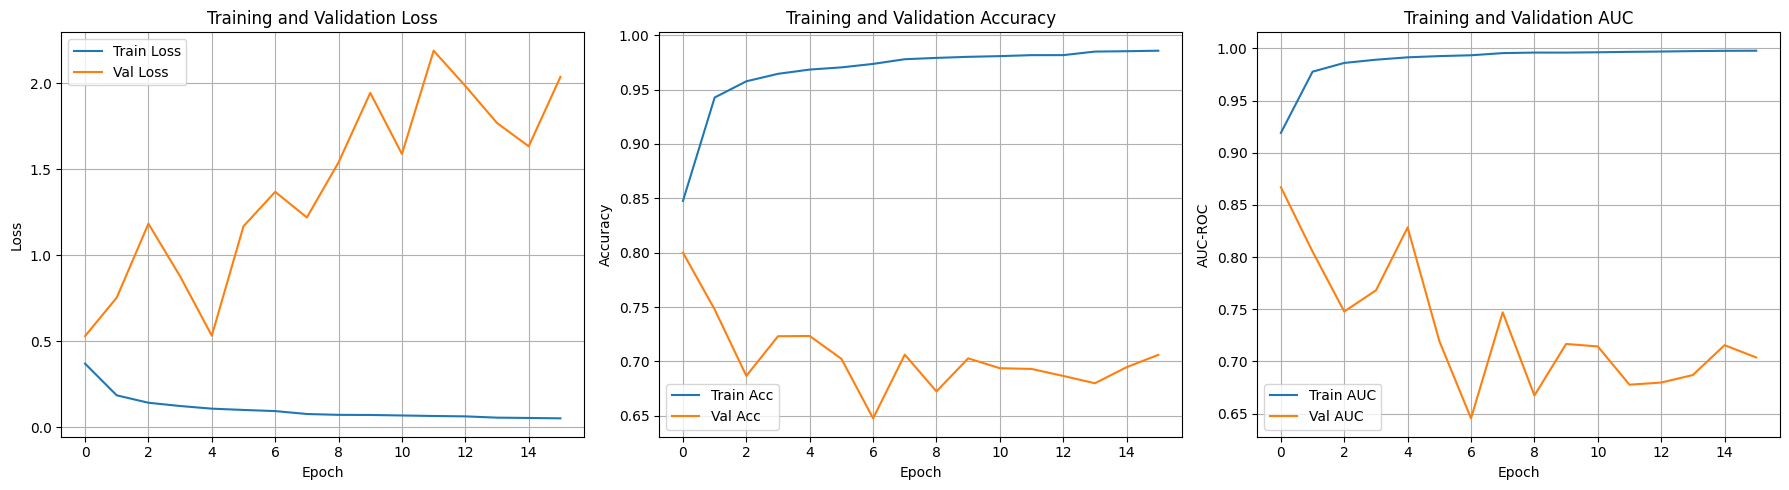

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(train_accs, label='Train Acc')
axes[1].plot(val_accs, label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

# AUC
axes[2].plot(train_aucs, label='Train AUC')
axes[2].plot(val_aucs, label='Val AUC')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC-ROC')
axes[2].set_title('Training and Validation AUC')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('training_history_context.png', dpi=150)
plt.show()

## STEP 11: Comprehensive Evaluation on Test Set

In [78]:
model.eval()
all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        
        outputs = model(X_batch)
        probs = torch.softmax(outputs, dim=1)
        _, preds = outputs.max(1)
        
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())
        all_labels.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# Compute metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, zero_division=0)
recall = recall_score(all_labels, all_preds, zero_division=0)
f1 = f1_score(all_labels, all_preds, zero_division=0)
try:
    auc_roc = roc_auc_score(all_labels, all_probs)
except ValueError:
    auc_roc = 0
try:
    logloss = log_loss(all_labels, all_probs)
except ValueError:
    logloss = 0

mae = mean_absolute_error(all_labels, all_preds)
mse = mean_squared_error(all_labels, all_preds)
rmse = np.sqrt(mse)

print('=' * 70)
print('COMPREHENSIVE MODEL EVALUATION - Context-Aware CNN1D')
print('=' * 70)

print('\nCATEGORY 1: BASIC CLASSIFICATION METRICS')
print('=' * 70)
print(f'1. ACCURACY: {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'2. PRECISION: {precision:.4f}')
print(f'3. RECALL (Abnormal): {recall:.4f}')
print(f'4. F1 SCORE: {f1:.4f}')
print(f'5. LOG LOSS: {logloss:.4f}')

print('\nCATEGORY 2: ROC CURVE AND AUC METRICS')
print('=' * 70)
print(f'6. AUC-ROC: {auc_roc:.4f}')

print('\nCATEGORY 3: ERROR METRICS')
print('=' * 70)
print(f'7a. MAE: {mae:.6f}')
print(f'7b. MSE: {mse:.6f}')
print(f'7c. RMSE: {rmse:.6f}')

print('\n' + '=' * 70)
print('CLASSIFICATION REPORT')
print('=' * 70)
print(classification_report(all_labels, all_preds, target_names=['Normal (0)', 'Abnormal (1)']))

print('\nSUMMARY')
print('=' * 70)
print(f'Accuracy:           {accuracy:.4f}')
print(f'Precision:          {precision:.4f}')
print(f'Recall (Abnormal):  {recall:.4f}')
print(f'F1 Score:           {f1:.4f}')
print(f'AUC-ROC:            {auc_roc:.4f}')

COMPREHENSIVE MODEL EVALUATION - Context-Aware CNN1D

CATEGORY 1: BASIC CLASSIFICATION METRICS
1. ACCURACY: 0.9852 (98.52%)
2. PRECISION: 0.9820
3. RECALL (Abnormal): 0.9509
4. F1 SCORE: 0.9662
5. LOG LOSS: 0.0722

CATEGORY 2: ROC CURVE AND AUC METRICS
6. AUC-ROC: 0.9899

CATEGORY 3: ERROR METRICS
7a. MAE: 0.014764
7b. MSE: 0.014764
7c. RMSE: 0.121506

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Normal (0)       0.99      1.00      0.99     13863
Abnormal (1)       0.98      0.95      0.97      3951

    accuracy                           0.99     17814
   macro avg       0.98      0.97      0.98     17814
weighted avg       0.99      0.99      0.99     17814


SUMMARY
Accuracy:           0.9852
Precision:          0.9820
Recall (Abnormal):  0.9509
F1 Score:           0.9662
AUC-ROC:            0.9899


## STEP 12: Confusion Matrix

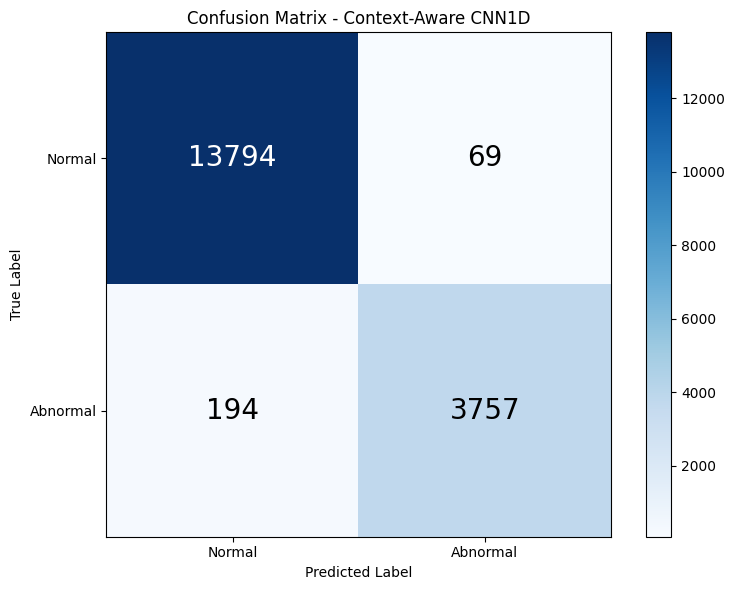


Confusion Matrix:
  True Normal  -> Predicted Normal: 13794 | Predicted Abnormal: 69
  True Abnormal -> Predicted Normal: 194 | Predicted Abnormal: 3757


In [79]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=[0, 1], yticks=[0, 1],
       xticklabels=['Normal', 'Abnormal'],
       yticklabels=['Normal', 'Abnormal'],
       title='Confusion Matrix - Context-Aware CNN1D',
       ylabel='True Label',
       xlabel='Predicted Label')

thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black',
                fontsize=20)

plt.tight_layout()
plt.savefig('confusion_matrix_context.png', dpi=150)
plt.show()

print(f'\nConfusion Matrix:')
print(f'  True Normal  -> Predicted Normal: {cm[0,0]} | Predicted Abnormal: {cm[0,1]}')
print(f'  True Abnormal -> Predicted Normal: {cm[1,0]} | Predicted Abnormal: {cm[1,1]}')

## STEP 13: ROC Curve

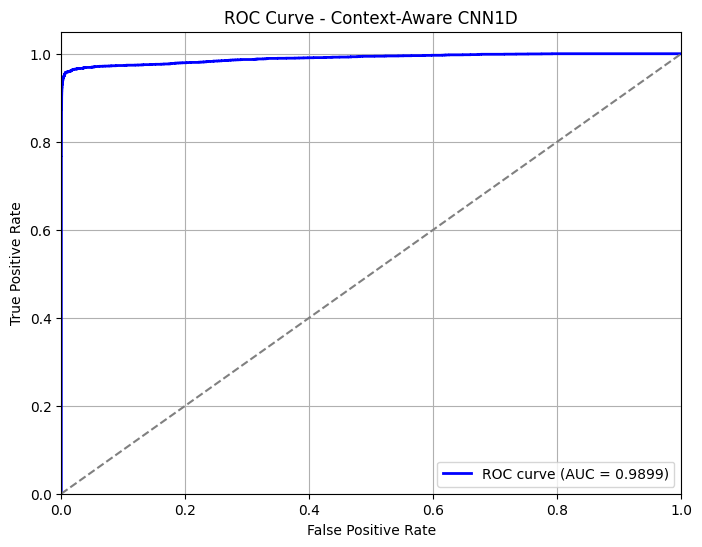

In [80]:
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'ROC curve (AUC = {auc_roc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Context-Aware CNN1D')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig('roc_curve_context.png', dpi=150)
plt.show()

## STEP 14: Save Model and Scaler

In [81]:
import joblib

# Save PyTorch model
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {
        'context_window_size': CONTEXT_WINDOW_SIZE,
        'beat_length': BEAT_LENGTH,
        'dropout': 0.5
    },
    'accuracy': accuracy,
    'auc_roc': auc_roc,
    'recall': recall,
}, 'context_ecg_model.pth')
print('Saved: context_ecg_model.pth')

# Save scaler
joblib.dump(scaler, 'context_ecg_scaler.pkl')
print('Saved: context_ecg_scaler.pkl')

# Save model config
model_config = {
    'context_window_size': CONTEXT_WINDOW_SIZE,
    'beat_length': BEAT_LENGTH,
    'flat_size': flat_size,
    'normalization': 'StandardScaler',
    'decision_threshold': 0.5,
    'input_shape': [CONTEXT_WINDOW_SIZE, BEAT_LENGTH],
    'output_classes': 2,
    'label_mapping': {
        '0': 'Normal',
        '1': 'Abnormal'
    },
    'metrics': {
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1),
        'auc_roc': float(auc_roc)
    }
}
with open('model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)
print('Saved: model_config.json')

Saved: context_ecg_model.pth
Saved: context_ecg_scaler.pkl
Saved: model_config.json


## STEP 15: Export to ONNX

In [82]:
print('Exporting to ONNX...')

model.eval()
model_cpu = model.cpu()

# Create dummy input: (batch, context_window_size, beat_length)
dummy_input = torch.randn(1, CONTEXT_WINDOW_SIZE, BEAT_LENGTH)
onnx_path = 'context_ecg_model.onnx'

try:
    torch.onnx.export(
        model_cpu,
        dummy_input,
        onnx_path,
        export_params=True,
        opset_version=13,
        do_constant_folding=True,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes={
            'input': {0: 'batch_size'},
            'output': {0: 'batch_size'}
        }
    )
    print(f'✓ ONNX model exported: {onnx_path}')
    
    # Verify ONNX model
    import onnxruntime as ort
    sess = ort.InferenceSession(onnx_path)
    
    # Test inference
    test_input = np.random.randn(1, CONTEXT_WINDOW_SIZE, BEAT_LENGTH).astype(np.float32)
    onnx_output = sess.run(None, {'input': test_input})[0]
    print(f'✓ ONNX model verified - output shape: {onnx_output.shape}')
    
except Exception as e:
    print(f'ONNX export error: {e}')
    print('PyTorch model is available for manual export')

Exporting to ONNX...
✓ ONNX model exported: context_ecg_model.onnx
ONNX export error: No module named 'onnxruntime'
PyTorch model is available for manual export


## STEP 16: Summary

In [83]:
print('=' * 70)
print('TRAINING COMPLETE - Context-Aware CNN1D')
print('=' * 70)

print(f'\n1. MODEL ARCHITECTURE:')
print(f'   - Input: ({CONTEXT_WINDOW_SIZE}, {BEAT_LENGTH}) - 7 beats of 200 samples')
print(f'   - Conv1D layers: 32 -> 64 -> 128 filters')
print(f'   - Global Average Pooling')
print(f'   - Dense: 128 -> 64 -> 2 (with dropout 0.5)')

print(f'\n2. ANTI-OVERFITTING TECHNIQUES:')
print(f'   - Dropout: 0.5')
print(f'   - BatchNorm after each Conv layer')
print(f'   - Weight Decay: 1e-3 (L2 regularization)')
print(f'   - Early Stopping: Patience {PATIENCE}')
print(f'   - ReduceLROnPlateau: Based on val AUC')
print(f'   - Gradient Clipping: max_norm=1.0')
print(f'   - Class Weighting: For imbalanced data')

print(f'\n3. DATA LEAKAGE PREVENTION:')
print(f'   - Record-wise split (no patient leakage)')
print(f'   - Scaler fit on TRAINING DATA ONLY')
print(f'   - Context window strictly enforced')

print(f'\n4. FINAL METRICS:')
print(f'   Accuracy:  {accuracy:.4f}')
print(f'   Precision: {precision:.4f}')
print(f'   Recall:    {recall:.4f}')
print(f'   F1 Score:  {f1:.4f}')
print(f'   AUC-ROC:   {auc_roc:.4f}')

print(f'\n5. OUTPUT FILES:')
print(f'   - context_ecg_model.onnx')
print(f'   - context_ecg_scaler.pkl')
print(f'   - model_config.json')
print(f'   - context_ecg_model.pth (PyTorch checkpoint)')

print(f'\n6. DEPLOYMENT:')
print(f'   - Use context_ecg_model.onnx with context_ecg_scaler.pkl')
print(f'   - Maintain rolling buffer of 7 beats')
print(f'   - Flatten (7 × {BEAT_LENGTH}) -> normalize -> reshape -> infer')
print(f'   - Threshold: 0.5 (configurable)')

print(f'\n7. LIVE TESTING:')
print(f'   - Use record 119 (excluded from training)')
print(f'   - Expected realistic performance')

print('\n' + '=' * 70)
print('Training complete!')
print('=' * 70)

TRAINING COMPLETE - Context-Aware CNN1D

1. MODEL ARCHITECTURE:
   - Input: (7, 200) - 7 beats of 200 samples
   - Conv1D layers: 32 -> 64 -> 128 filters
   - Global Average Pooling
   - Dense: 128 -> 64 -> 2 (with dropout 0.5)

2. ANTI-OVERFITTING TECHNIQUES:
   - Dropout: 0.5
   - BatchNorm after each Conv layer
   - Weight Decay: 1e-3 (L2 regularization)
   - Early Stopping: Patience 15
   - ReduceLROnPlateau: Based on val AUC
   - Gradient Clipping: max_norm=1.0
   - Class Weighting: For imbalanced data

3. DATA LEAKAGE PREVENTION:
   - Record-wise split (no patient leakage)
   - Scaler fit on TRAINING DATA ONLY
   - Context window strictly enforced

4. FINAL METRICS:
   Accuracy:  0.9852
   Precision: 0.9820
   Recall:    0.9509
   F1 Score:  0.9662
   AUC-ROC:   0.9899

5. OUTPUT FILES:
   - context_ecg_model.onnx
   - context_ecg_scaler.pkl
   - model_config.json
   - context_ecg_model.pth (PyTorch checkpoint)

6. DEPLOYMENT:
   - Use context_ecg_model.onnx with context_ecg_scal